# Mean Climate Synthetic Metrics: v4P versus CMIP

Mean-climate synthetic metrics for the four standalone v4P comparison runs.


In [22]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import metrics_group_merger
import synthetic_metrics_workflow
importlib.reload(metrics_group_merger)
importlib.reload(synthetic_metrics_workflow)

from metrics_group_merger import MetricsGroup, PCMDIRun, merge_metrics_group
from synthetic_metrics_workflow import (
    dataset_for_merged_group,
    make_comparison_parameters,
    run_synthetic_plots,
)


In [23]:
# Plot setup: optionally merge one test group, then compare it against CMIP.
CLIM_MVO_V4P_CASE_ID = "v20260212"
CLIM_MVO_V4P_RUN_PLOTS = True
CLIM_MVO_V4P_TITLE_LABEL = "E3SM versus CMIP"

# Set CLIM_MVO_V4P_RUN_MERGE=True when raw run JSONs should be merged before plotting.
CLIM_MVO_V4P_RUN_MERGE = False
CLIM_MVO_V4P_CLEAN_MERGED_OUTPUT = False
CLIM_MVO_V4P_DRY_RUN_MERGE = False
CLIM_MVO_V4P_DEBUG = True

# Merged metrics location and local config.
CLIM_MVO_V4P_METRICS_DATA_ROOT = Path("/global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data")
CLIM_MVO_V4P_METRIC_CONFIG_FILE = PROJECT_ROOT / "config" / "synthetic_metrics_list.json"
CLIM_MVO_V4P_OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output")

# Raw PCMDI diagnostic runs to merge. Each entry matches the PCMDI run setup:
# raw metrics are read from www / case / "pcmdi_diags" / run_type / "metrics_data".
# Plot the merged climo dataset, including when the merge step is skipped.
CLIM_MVO_V4P_TEST_COMBINED = True
CLIM_MVO_V4P_TEST_MODEL_ONLY = False
CLIM_MVO_V4P_TEST_MIP = "e3sm"
CLIM_MVO_V4P_TEST_EXP = "historical"
CLIM_MVO_V4P_TEST_MERGED_GROUP = "climo"
CLIM_MVO_V4P_TEST_GROUP_LABEL = "E3SM"
CLIM_MVO_V4P_TEST_RUNS = [
    PCMDIRun(
        case="20231209.v3.LR.piControl-spinup.chrysalis",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260531",
        output_name="v3.LR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        model_name="v3-HR_test6-1",
        metrics_case_id="v20260601",
        output_name="v3.HR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20260204.ne256.WCYCLXX1850.SOI",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260601",
        output_name="v4P.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        model_name="EAMXX_test2_1",
        metrics_case_id="v20260531",
        output_name="v4P.AMIP",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
]
CLIM_MVO_V4P_TEST_HIGHLIGHT_MODELS = [run.output_name or run.model_name for run in CLIM_MVO_V4P_TEST_RUNS]

CLIM_MVO_V4P_TEST_RAW_GROUP = MetricsGroup(
    name=CLIM_MVO_V4P_TEST_MERGED_GROUP,
    model_pattern="*",
    runs=CLIM_MVO_V4P_TEST_RUNS,
    mips=[CLIM_MVO_V4P_TEST_MIP],
    exps=[CLIM_MVO_V4P_TEST_EXP],
    case_id=CLIM_MVO_V4P_CASE_ID,
    model_rename=None,
    movs_years=(1850, 2014),
    movs_modes="NAM,NAO,PNA,NPO,SAM,PSA1,PSA2,PDO,NPGO,AMO",
    movs_obses=(
        "NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,"
        "HadISST,HadISST,HadISST"
    ),
    enso_collections="ENSO_perf,ENSO_tel,ENSO_proc",
    enso_obses="ERA5,ERA5,ERA5",
)


2026-08-28 16:44:54,503 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:638) >> Generating synthetic metrics plots for case_id=v20260212
2026-08-28 16:44:54,503 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:643) >> Generating figure_set=mean_climate metrics=['mae_xy', 'cor_xy', 'rms_xy', 'bias_xy', 'rms_xyt'] for case_id=v20260212
2026-08-28 16:44:54,505 [INFO]: synthetic_metrics_plotter.py(generate:363) >> Generating synthetic metrics plots ...
2026-08-28 16:44:54,505 [INFO]: synthetic_metrics_plotter.py(generate:389) >> Processing metric: mean_climate
2026-08-28 16:44:54,506 [INFO]: synthetic_metrics_plotter.py(_handle_mean_climate:409) >> Handling mean climate…
2026-08-28 16:44:54,508 [INFO]: clim_metrics_reader.py(_load_combined_metrics:120) >> Loading reference metrics from 27 files...
2026-08-28 16:44:54,509 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:75) >> file_paths= (27)
2026-08-28 16:44:54,510 [INFO]: clim_metrics_reader.py(_load_clim_m

[INFO] Using PROJ data: /global/u2/z/zhan391/.conda/envs/e3sm_analysis/share/proj
Test group: E3SM
Reference group: CMIP
Models (0): []
Results: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/model_vs_obs
mean_climate: ['mae_xy', 'cor_xy', 'rms_xy', 'bias_xy', 'rms_xyt']


2026-08-28 16:44:57,151 [INFO]: clim_metrics_reader.py(_load_combined_metrics:120) >> Loading reference metrics from 23 files...
2026-08-28 16:44:57,153 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:75) >> file_paths= (23)
2026-08-28 16:44:57,154 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:77) >> 0. /global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate/e3sm/climo/v20260212/pr.e3sm.climo.v20260212.json
2026-08-28 16:44:57,154 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:77) >> 1. /global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate/e3sm/climo/v20260212/psl.e3sm.climo.v20260212.json
2026-08-28 16:44:57,155 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:77) >> 2. /global/cfs/cdirs/e3sm/diagnostics/pcmdi_data/metrics_data/mean_climate/e3sm/climo/v20260212/rlds.e3sm.climo.v20260212.json
2026-08-28 16:44:57,156 [INFO]: clim_metrics_reader.py(_load_clim_metrics_from_files:77) >> 3. /global/cfs/c

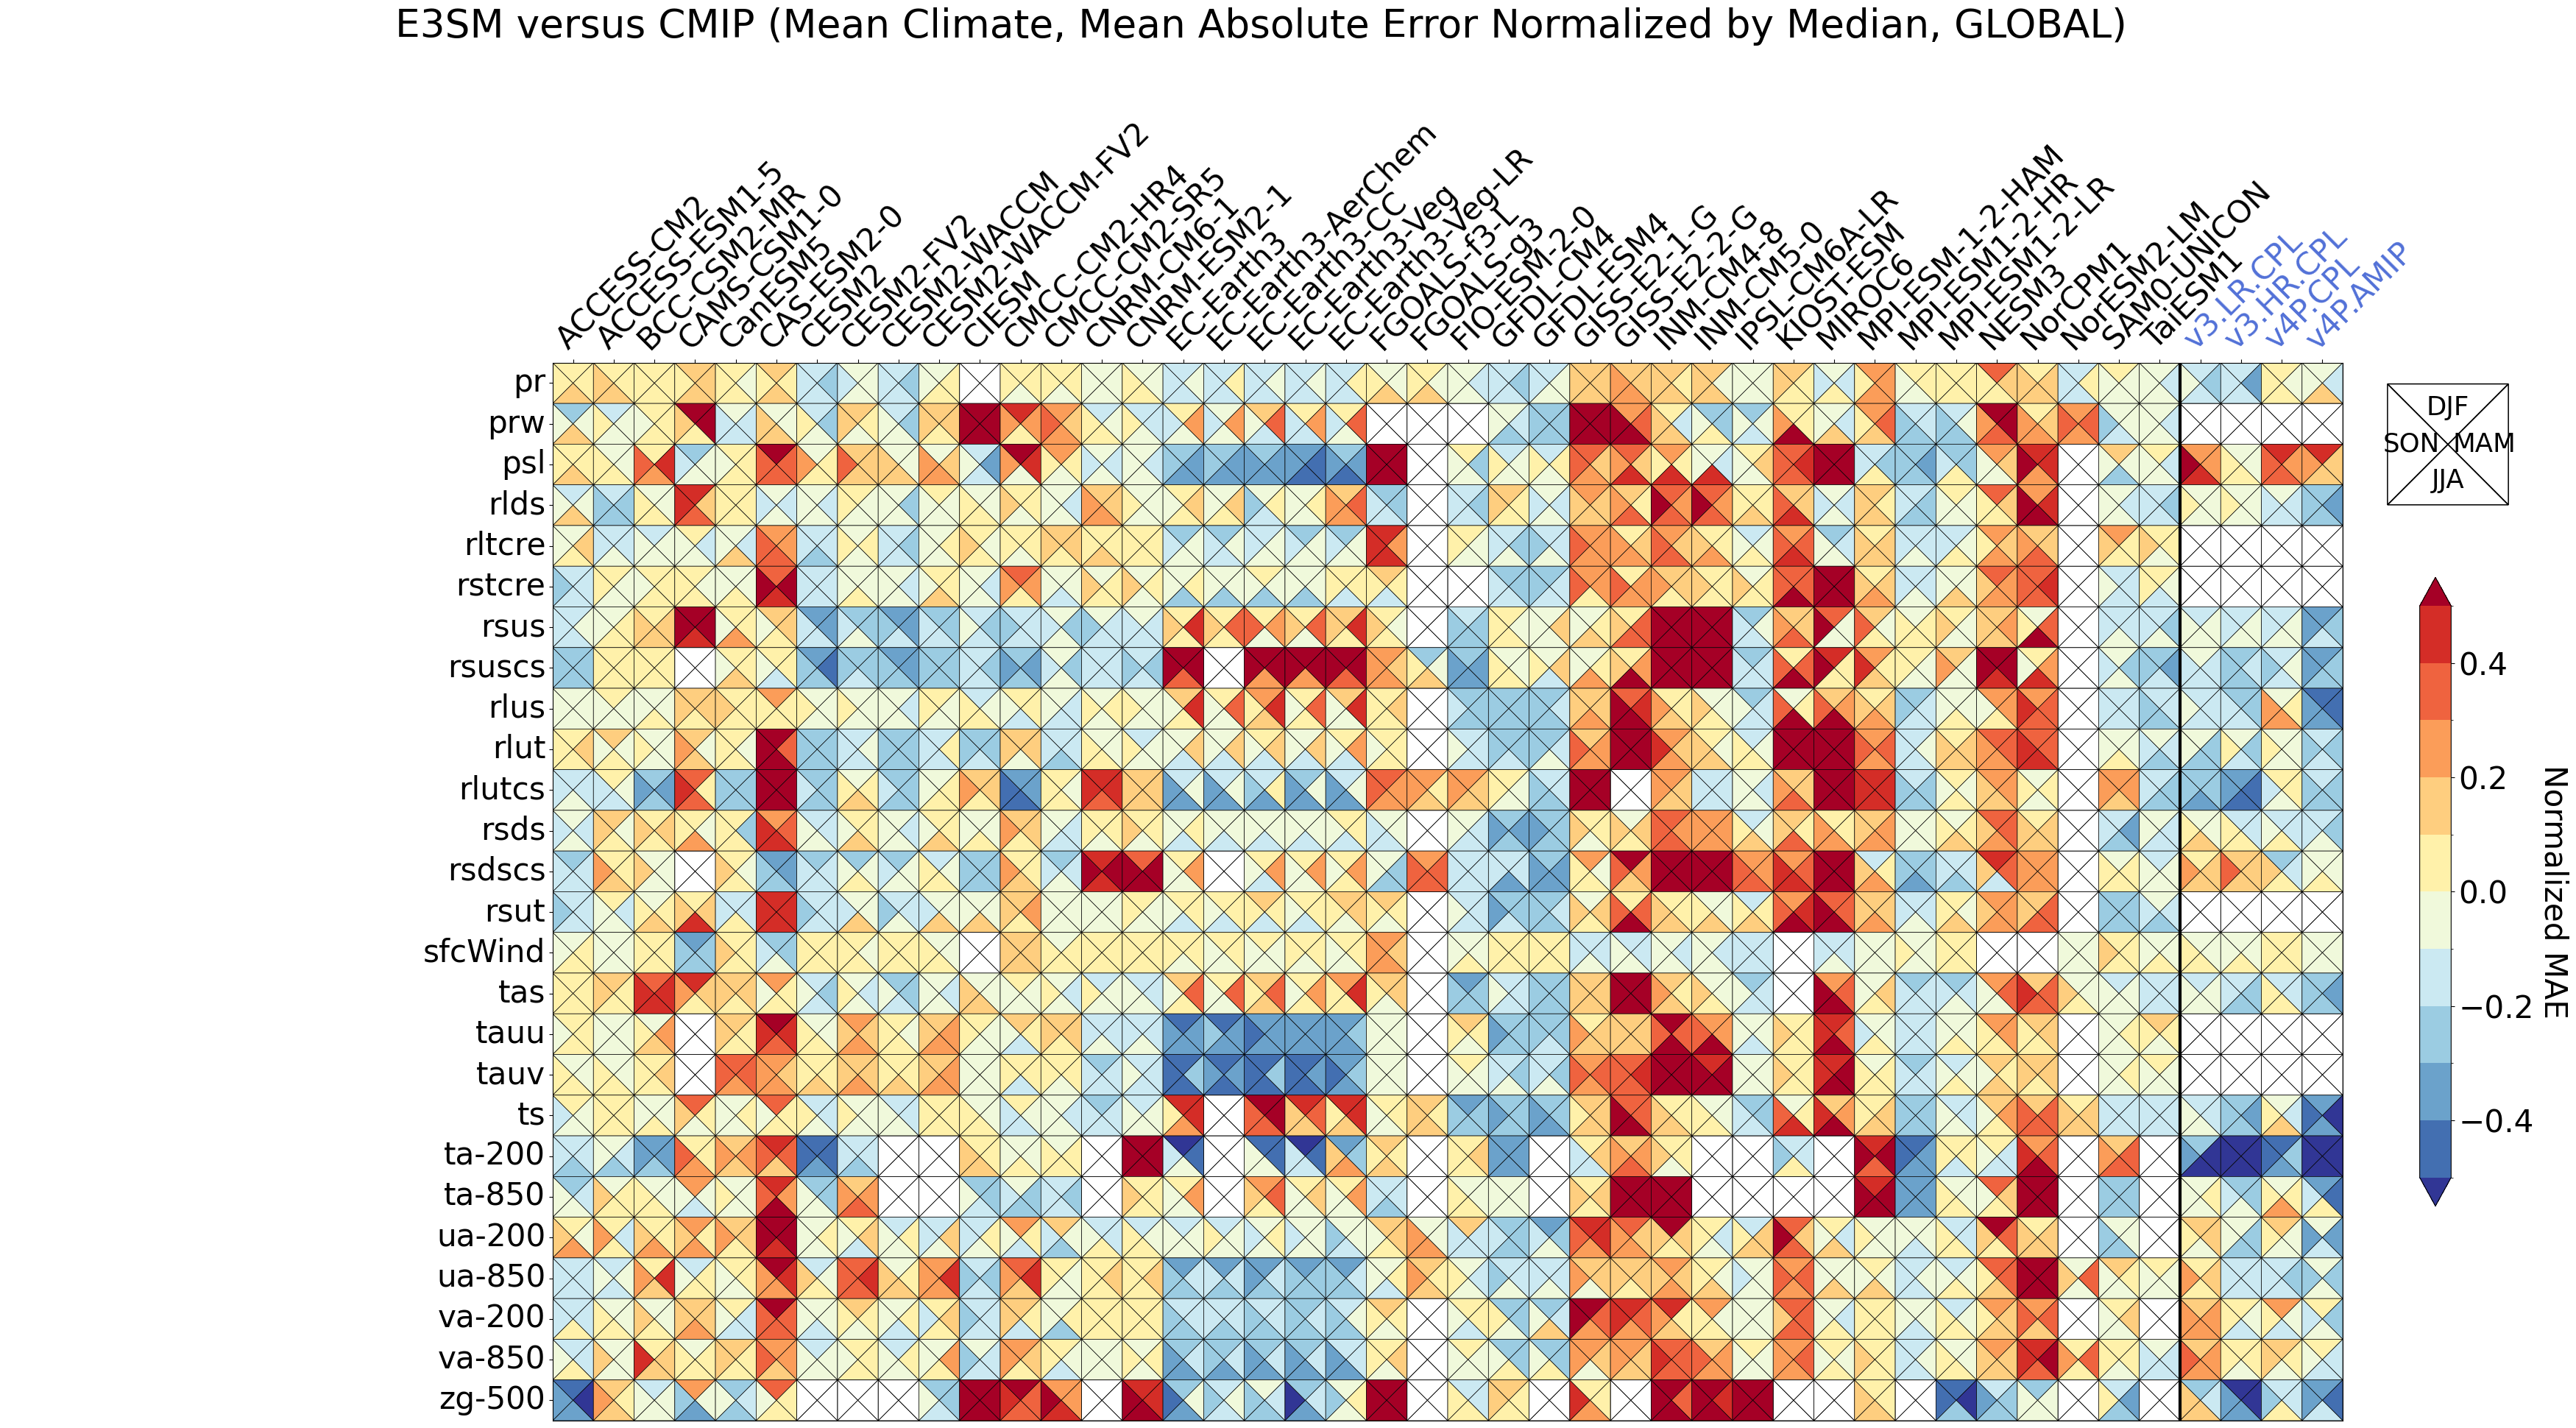

2026-08-28 16:45:02,690 [INFO]: synthetic_metrics_plotter.py(mean_climate_plot_driver:698) >> Processing Portrait  Plots for mean_climate global cor_xy....
2026-08-28 16:45:02,741 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1153) >> [Portrait]: No groupd mean models to plot (mean_list empty).
2026-08-28 16:45:02,742 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1155) >> [Portrait]: No extra mean models to plot (meanx_list empty).
2026-08-28 16:45:02,743 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.CPL', 'v3.HR.CPL', 'v4P.CPL', 'v4P.AMIP']


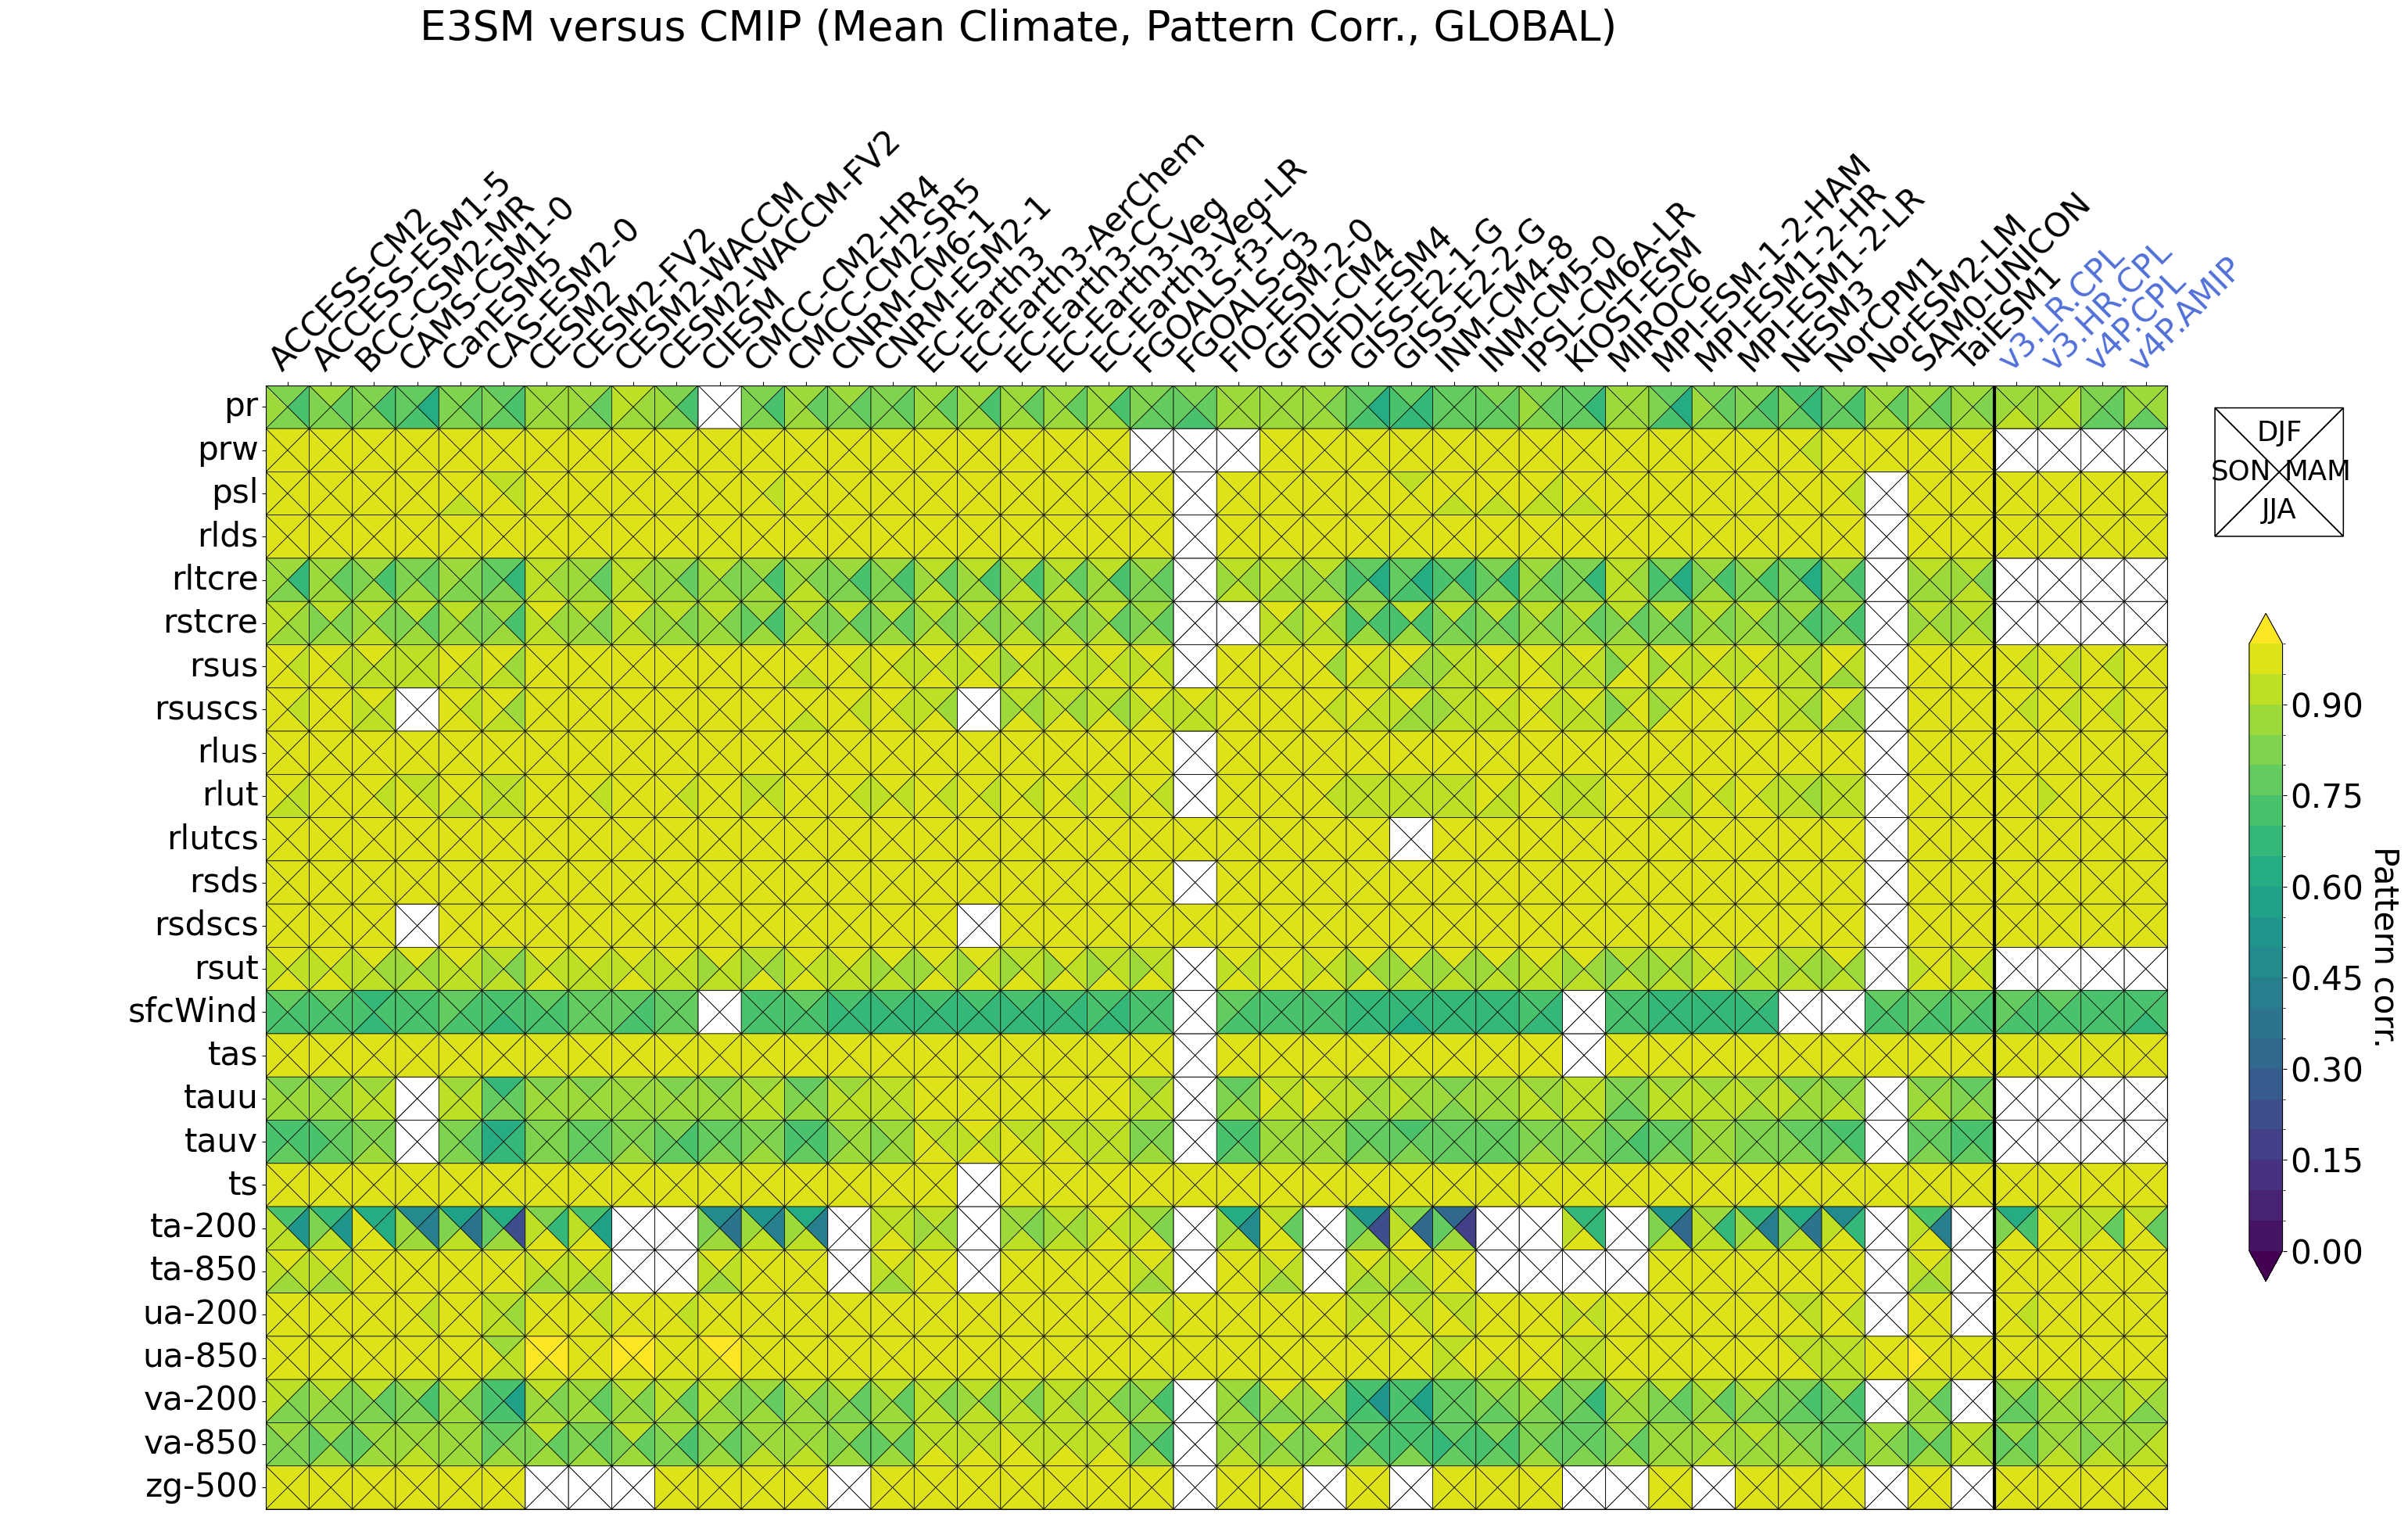

2026-08-28 16:45:04,919 [INFO]: synthetic_metrics_plotter.py(mean_climate_plot_driver:698) >> Processing Portrait  Plots for mean_climate global rms_xy....
2026-08-28 16:45:04,983 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1153) >> [Portrait]: No groupd mean models to plot (mean_list empty).
2026-08-28 16:45:04,985 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1155) >> [Portrait]: No extra mean models to plot (meanx_list empty).
2026-08-28 16:45:04,985 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.CPL', 'v3.HR.CPL', 'v4P.CPL', 'v4P.AMIP']


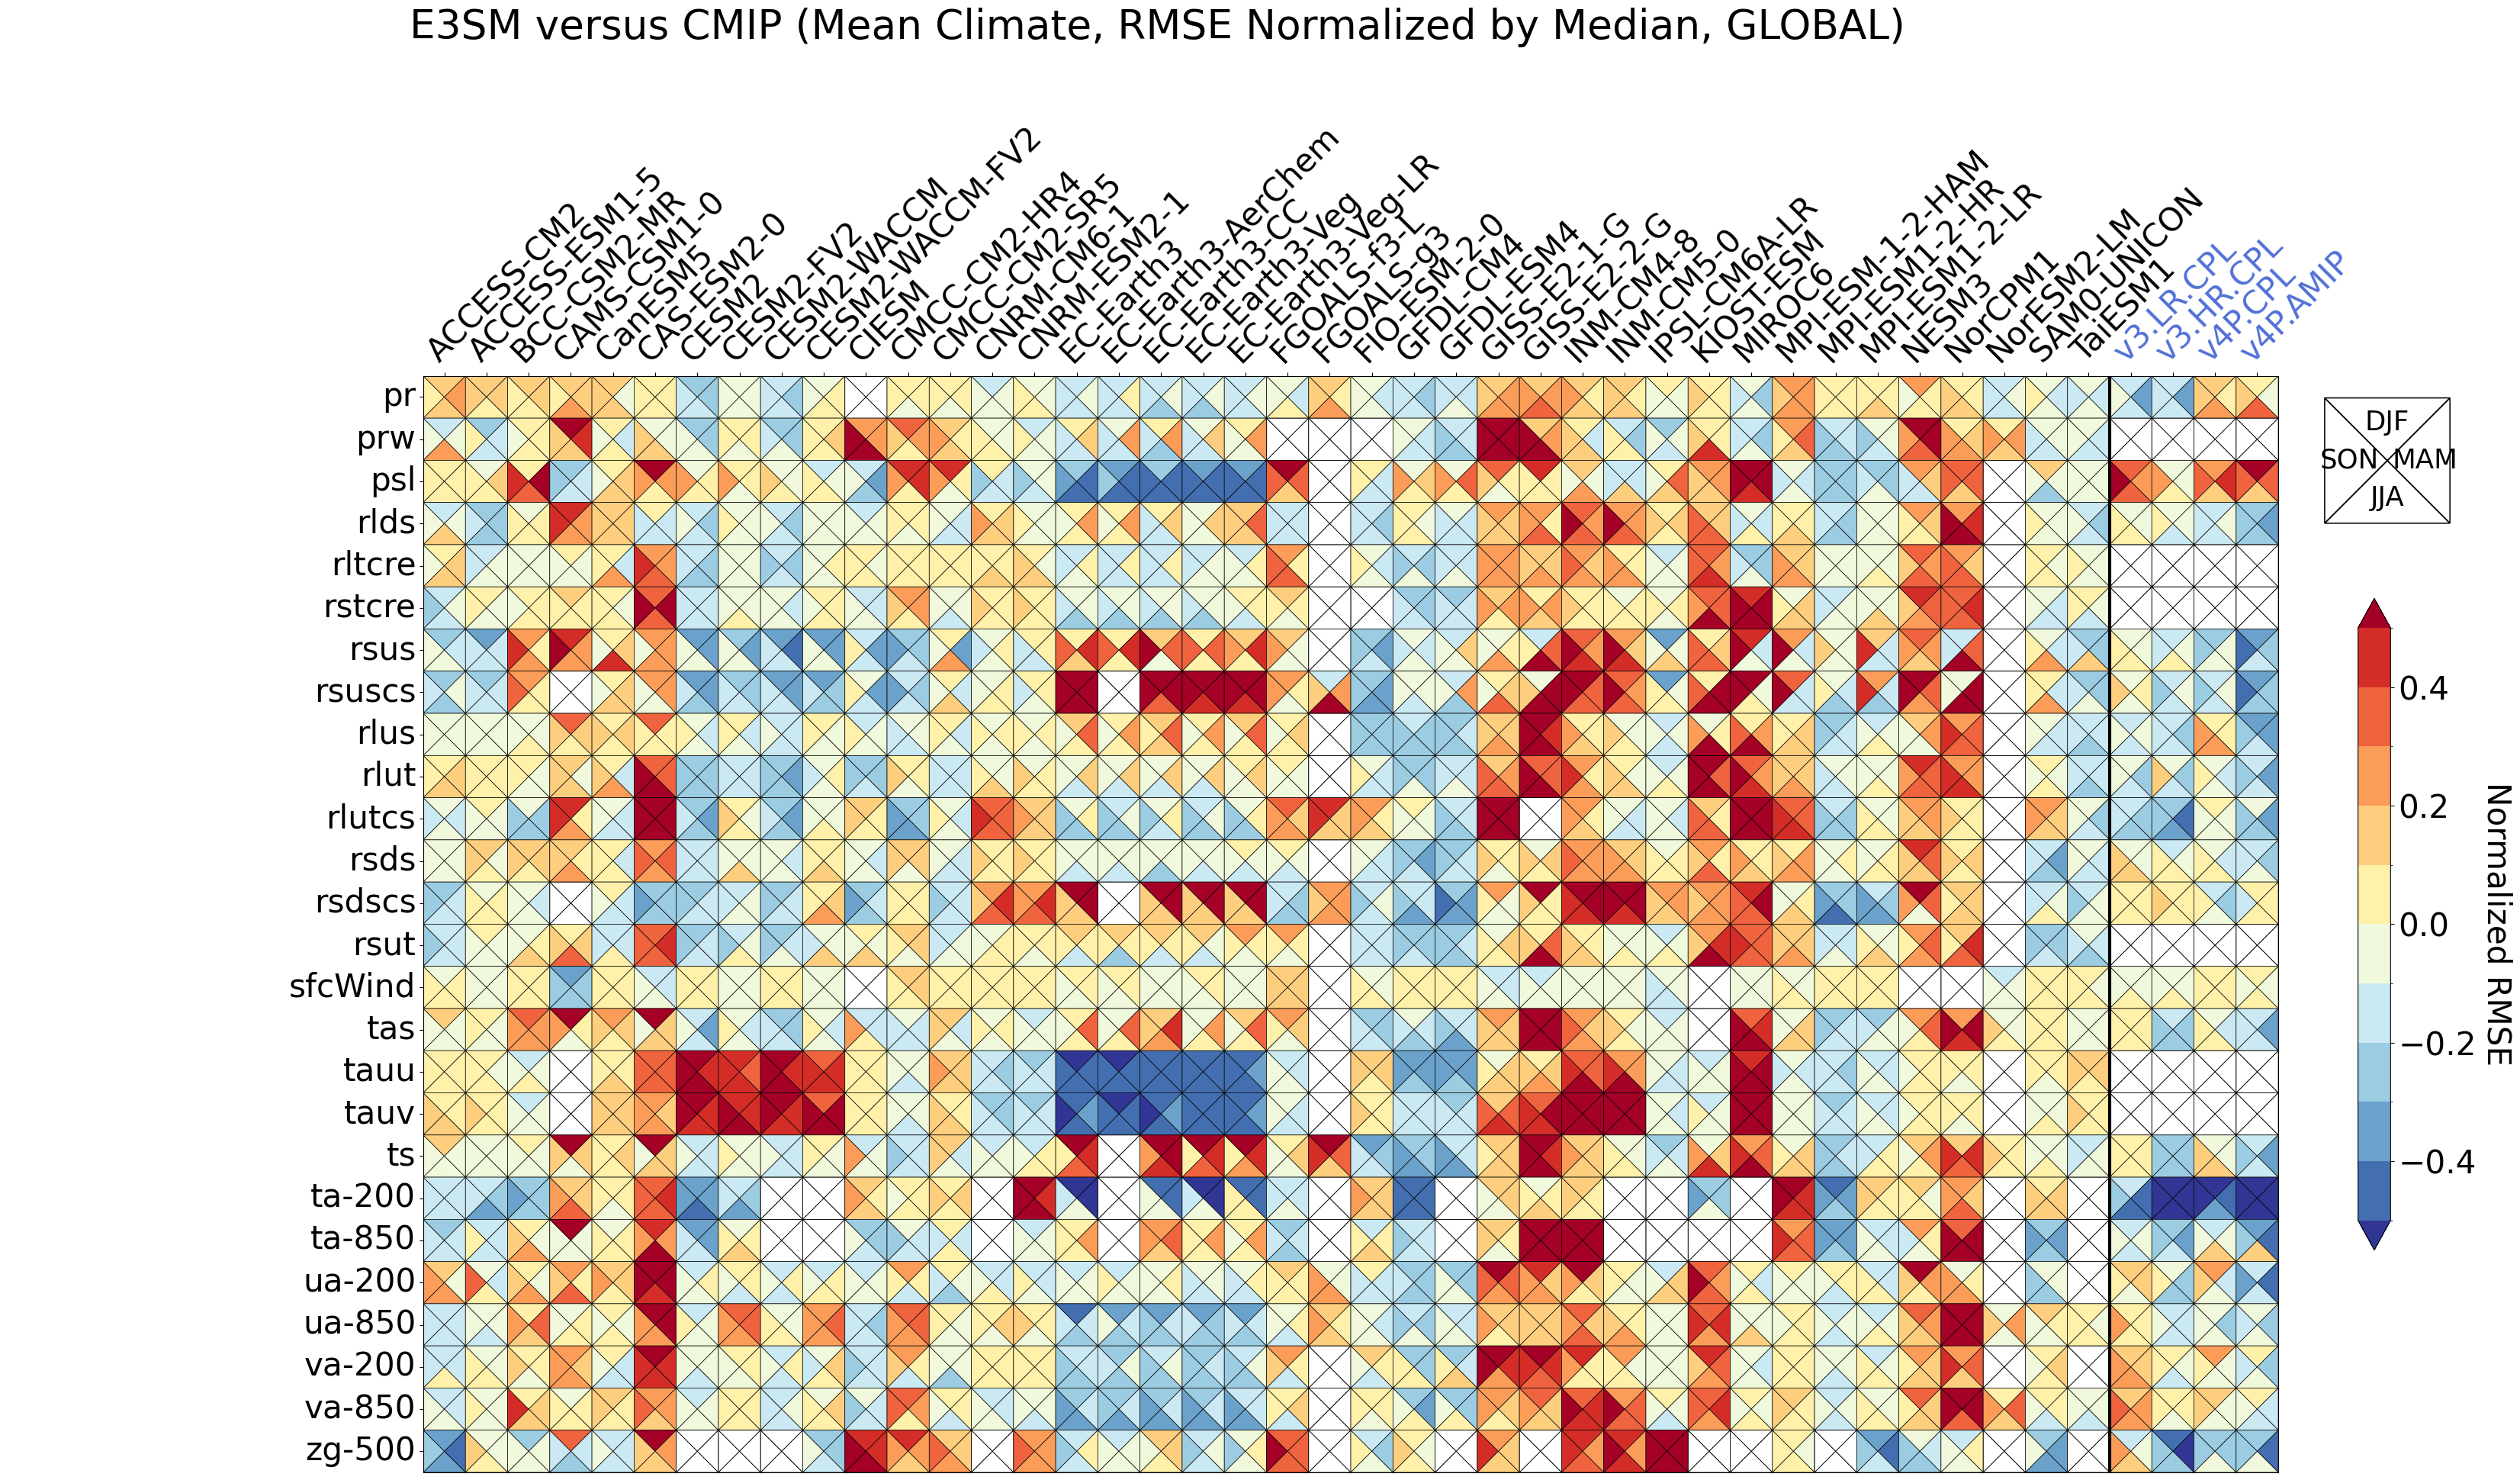

2026-08-28 16:45:07,137 [INFO]: synthetic_metrics_plotter.py(mean_climate_plot_driver:801) >> Processing Parallel Coordinate Plots for mean_climate global bias_xy....
2026-08-28 16:45:07,138 [INFO]: synthetic_metrics_plotter.py(mean_climate_plot_driver:801) >> Processing Parallel Coordinate Plots for mean_climate global rms_xyt....


Models in the second group: ['v3.HR.CPL', 'v3.LR.CPL', 'v4P.AMIP', 'v4P.CPL']


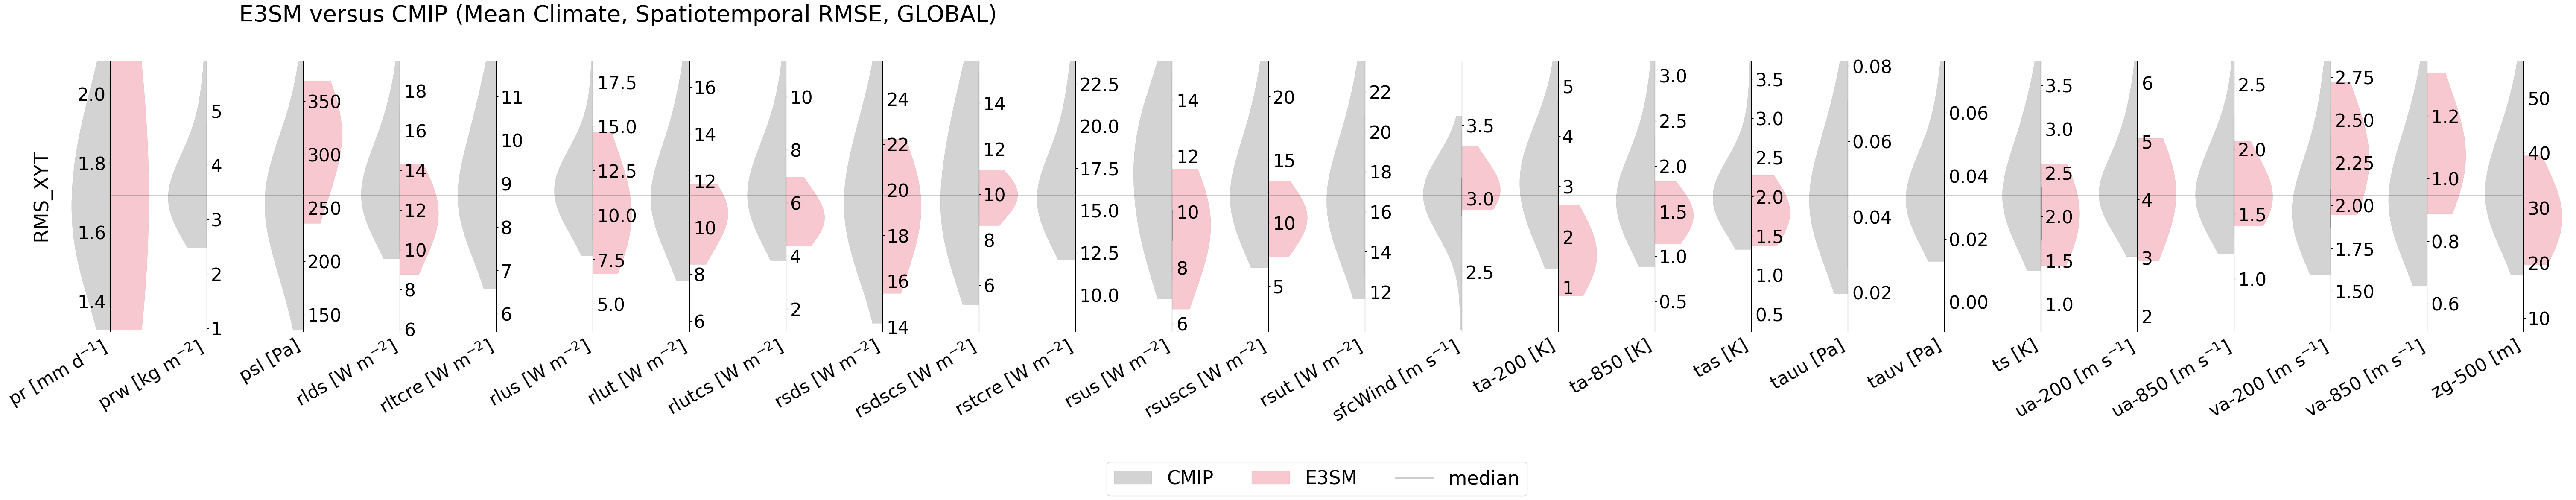

In [24]:
if CLIM_MVO_V4P_RUN_MERGE:
    merge_metrics_group(
        CLIM_MVO_V4P_TEST_RAW_GROUP,
        metrics_root=CLIM_MVO_V4P_METRICS_DATA_ROOT,
        run_type="model_vs_obs",
        enable_clim=True,
        enable_movs=False,
        enable_enso=False,
        strict=True,
        verbose=True,
        dry_run=CLIM_MVO_V4P_DRY_RUN_MERGE,
        clean=CLIM_MVO_V4P_CLEAN_MERGED_OUTPUT,
    )
    CLIM_MVO_V4P_TEST_COMBINED = True

# Merged test group consumed by the plot workflow.
CLIM_MVO_V4P_TEST_DATASET = dataset_for_merged_group(
    mip=CLIM_MVO_V4P_TEST_MIP,
    group=CLIM_MVO_V4P_TEST_MERGED_GROUP,
    case_id=CLIM_MVO_V4P_CASE_ID,
    root=CLIM_MVO_V4P_METRICS_DATA_ROOT,
)

# Reference setup. Use built-in CMIP defaults from CLIM_MVO_V4P_METRICS_DATA_ROOT.
CLIM_MVO_V4P_REF_GROUP_LABEL = "CMIP"
CLIM_MVO_V4P_REF_DATASET = None
CLIM_MVO_V4P_ALIGN_WITH_CMIP = True

CLIM_MVO_V4P_SHOW_MEAN_COLUMNS = False
CLIM_MVO_V4P_MEAN_GROUP1_NAME = None #"CMIP (mean)"
CLIM_MVO_V4P_MEAN_GROUP2_NAME = None #"E3SM (mean)"

# Explicit metrics and figure family.
CLIM_MVO_V4P_METRICS = ("mae_xy", "cor_xy", "rms_xy", "bias_xy", "rms_xyt")
CLIM_MVO_V4P_SHOW_FIGURES = True
CLIM_MVO_V4P_CLIM_VIEWER = True
CLIM_MVO_V4P_MOVA_VIEWER = False
CLIM_MVO_V4P_MOVC_VIEWER = False
CLIM_MVO_V4P_ENSO_VIEWER = False

# Plot settings.
CLIM_MVO_V4P_CLIM_VARS = (
    "pr,prw,psl,rlds,rldscs,rltcre,rstcre,rsus,rsuscs,rlus,rlut,rlutcs,"
    "rsds,rsdscs,rsut,rsutcs,rtmt,sfcWind,tas,tauu,tauv,ts,ta-200,ta-850,"
    "ua-200,ua-850,va-200,va-850,zg-500"
)
CLIM_MVO_V4P_CLIM_REGIONS = "global"
CLIM_MVO_V4P_MOVS_GROUP = "cbf"
CLIM_MVO_V4P_ATM_MODES = None
CLIM_MVO_V4P_ATM_OBS = "NOAA-20C"
CLIM_MVO_V4P_CPL_MODES = None
CLIM_MVO_V4P_CPL_OBS = "HadISST"
CLIM_MVO_V4P_ERROR_NORM = "reference"
CLIM_MVO_V4P_FIGURE_FORMAT = "pdf"
CLIM_MVO_V4P_FONT_SIZE = 32
CLIM_MVO_V4P_FIGURE_SIZE = (60.0, 20.0)  # Backward-compatible fallback.
CLIM_MVO_V4P_PORTRAIT_FIGURE_SIZE = (70.0, 20.0)
CLIM_MVO_V4P_PARCOORD_FIGURE_SIZE = (70.0, 20.0)  # More column spacing.

CLIM_MVO_V4P_EXCLUDE_VARS = {
    "E3SM-1-0": ["ta-850"],
    "E3SM-1-1-ECA": ["ta-850"],
    "CIESM": ["pr"],
    "KIOST-ESM": ["zg-500", "ta-850"],
    "GISS-E2-2-G": ["rlutcs", "zg-500"],
}
CLIM_MVO_V4P_EXCLUDE_MODELS = ["E3SM-1-0", "E3SM-1-1", "E3SM-1-1-ECA", "E3SM-2-0", "E3SM-2-1"]
CLIM_MVO_V4P_EXTRA_GROUPS_NAME = [""]

clim_mvo_v4p_parameters = make_comparison_parameters(
    case_id=CLIM_MVO_V4P_CASE_ID,
    ref_group=CLIM_MVO_V4P_REF_GROUP_LABEL,
    test_group=CLIM_MVO_V4P_TEST_GROUP_LABEL,
    ref_dataset=CLIM_MVO_V4P_REF_DATASET,
    test_dataset=CLIM_MVO_V4P_TEST_DATASET,
    test_highlight_models=CLIM_MVO_V4P_TEST_HIGHLIGHT_MODELS,
    metrics_root=CLIM_MVO_V4P_METRICS_DATA_ROOT,
    out_dir=CLIM_MVO_V4P_OUTPUT_DIR,
    align_with_cmip=CLIM_MVO_V4P_ALIGN_WITH_CMIP,
    test_combined=CLIM_MVO_V4P_TEST_COMBINED,
    test_model_only=CLIM_MVO_V4P_TEST_MODEL_ONLY,
    show_mean_columns=CLIM_MVO_V4P_SHOW_MEAN_COLUMNS,
    clim_vars=CLIM_MVO_V4P_CLIM_VARS,
    clim_regions=CLIM_MVO_V4P_CLIM_REGIONS,
    movs_group=CLIM_MVO_V4P_MOVS_GROUP,
    error_norm=CLIM_MVO_V4P_ERROR_NORM,
    exclude_vars=CLIM_MVO_V4P_EXCLUDE_VARS,
    exclude_models=CLIM_MVO_V4P_EXCLUDE_MODELS,
    atm_modes=CLIM_MVO_V4P_ATM_MODES,
    atm_obs=CLIM_MVO_V4P_ATM_OBS,
    cpl_modes=CLIM_MVO_V4P_CPL_MODES,
    cpl_obs=CLIM_MVO_V4P_CPL_OBS,
    figure_format=CLIM_MVO_V4P_FIGURE_FORMAT,
    clim_font_size=CLIM_MVO_V4P_FONT_SIZE,
    clim_figure_size=CLIM_MVO_V4P_FIGURE_SIZE,
    clim_portrait_figure_size=CLIM_MVO_V4P_PORTRAIT_FIGURE_SIZE,
    clim_parcoord_figure_size=CLIM_MVO_V4P_PARCOORD_FIGURE_SIZE,
    clim_viewer=CLIM_MVO_V4P_CLIM_VIEWER,
    mova_viewer=CLIM_MVO_V4P_MOVA_VIEWER,
    movc_viewer=CLIM_MVO_V4P_MOVC_VIEWER,
    enso_viewer=CLIM_MVO_V4P_ENSO_VIEWER,
    mean_group1_name=CLIM_MVO_V4P_MEAN_GROUP1_NAME,
    mean_group2_name=CLIM_MVO_V4P_MEAN_GROUP2_NAME,
    extra_groups_name=CLIM_MVO_V4P_EXTRA_GROUPS_NAME,
)

if CLIM_MVO_V4P_RUN_PLOTS:
    run_synthetic_plots(
        clim_mvo_v4p_parameters,
        title_label=CLIM_MVO_V4P_TITLE_LABEL,
        metric_file=CLIM_MVO_V4P_METRIC_CONFIG_FILE,
        metric_selection={"mean_climate": CLIM_MVO_V4P_METRICS},
        show_figures=CLIM_MVO_V4P_SHOW_FIGURES,
        debug=CLIM_MVO_V4P_DEBUG,
    )
else:
    print("Set CLIM_MVO_V4P_RUN_PLOTS = True to generate figures.")
